# US Consumer Price Index — Time Series Analysis

## Objective

This notebook applies the learnt Time Series processing methodology to model and forecast the
US Consumer Price Index (CPI) monthly data. The goal is to identify an
appropriate model, validate its residuals, and evaluate its
out-of-sample forecasting performance.

## Data

- **Source:** US Bureau of Labor Statistics (BLS) via FRED
- **Variable:** CPI Index (all items, not seasonally adjusted)
- **Frequency:** Monthly
- **Training set:** January 2010 – December 2018 (108 observations)
- **Test set:** January – December 2019 (12 observations)

**Remark**: the data has been specifically chosen in that time period so that our study is not affected by worldwide crises like the COVID-19 in 2020 and the 2008 crisis

## Methodology

1. Exploratory analysis and variance stabilization (Box-Cox)
2. Stationarity analysis (ADF test, detrending, differencing)
3. Model identification (ACF/PACF)
4. Model estimation and selection (AIC, BIC)
5. Residual diagnostics (Ljung-Box, Shapiro-Wilk, Runs Test)
6. Forecasting and out-of-sample evaluation


# 1. loading the necessary packages and data

In [ ]:
install.packages(c(
  "readr", "dplyr", "ggplot2", "forecast", "tseries",
  "urca", "lmtest", "randtests", "nortest"
))

In [2]:
library(readr)
library(dplyr)
library(ggplot2)
library(forecast)
library(tseries)
library(urca)
library(lmtest)
library(randtests)
library(nortest)
options()


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



Attaching package: ‘randtests’


The following object is masked from ‘package:tseries’:

    runs.test




$add.smooth
[1] TRUE

$bitmapType
[1] "cairo"

$browser
[1] ""

$browserNLdisabled
[1] FALSE

$callr.condition_handler_cli_message
function (msg) 
{
    custom_handler <- getOption("cli.default_handler")
    if (is.function(custom_handler)) {
        custom_handler(msg)
    }
    else {
        cli_server_default(msg)
    }
}
<bytecode: 0x639c3f64c8a0>
<environment: namespace:cli>

$catch.script.errors
[1] FALSE

$CBoundsCheck
[1] FALSE

$check.bounds
[1] FALSE

$citation.bibtex.max
[1] 1

$continue
[1] "+ "

$contrasts
        unordered           ordered 
"contr.treatment"      "contr.poly" 

$crayon.enabled
[1] TRUE

$defaultPackages
[1] "datasets"  "utils"     "grDevices" "graphics"  "stats"     "methods"  

$demo.ask
[1] "default"

$deparse.cutoff
[1] 60

$device
function (filename = null_filename, ...) 
ok_device(filename, ...)
<bytecode: 0x639c404ef938>
<environment: 0x639c404ef4a0>

$device.ask.default
[1] FALSE

$digits
[1] 7

$dvipscmd
[1] "dvips"

$echo
[1] FALSE

$editor
[1]

In [3]:
data <- read.csv("data/cpiai.csv")
head(data)

,Date,Index,Inflation
,<chr>,<dbl>,<dbl>
1,1913-01-01,9.8,0.00
2,1913-02-01,9.8,0.00
3,1913-03-01,9.8,0.00
4,1913-04-01,9.8,0.00
5,1913-05-01,9.7,-1.02
6,1913-06-01,9.8,1.03


# 2. Exploring the Data

In [4]:
summary(data)

     Date               Index          Inflation     
 Length:1332        Min.   :  9.70   Min.   :-3.160  
 Class :character   1st Qu.: 17.50   1st Qu.: 0.000  
 Mode  :character   Median : 34.80   Median : 0.240  
                    Mean   : 87.26   Mean   : 0.261  
                    3rd Qu.:155.85   3rd Qu.: 0.550  
                    Max.   :307.79   Max.   : 5.880  

In [5]:
df1 <- data |>
  filter(Date >= "2010-01-01" & Date <= "2018-12-01") |>
  select(time = Date, y = Index)
dft <- data |>
  filter(Date >= "2019-01-01" & Date <= "2019-12-01") |>
  select(time = Date, y = Index)

In [6]:
head(df1)

,time,y
,<chr>,<dbl>
1,2010-01-01,216.687
2,2010-02-01,216.741
3,2010-03-01,217.631
4,2010-04-01,218.009
5,2010-05-01,218.178
6,2010-06-01,217.965


In [7]:
df1 <- df1 |>
  mutate(time = as.Date(time, format = "%Y-%m-%d")) |>
  arrange(time)

dft <- dft |>
  mutate(time = as.Date(time, format = "%Y-%m-%d")) |>
  arrange(time)

In [8]:
head(df1)
tail(df1)

,time,y
,<date>,<dbl>
1,2010-01-01,216.687
2,2010-02-01,216.741
3,2010-03-01,217.631
4,2010-04-01,218.009
5,2010-05-01,218.178
6,2010-06-01,217.965


,time,y
,<date>,<dbl>
103,2018-07-01,252.006
104,2018-08-01,252.146
105,2018-09-01,252.439
106,2018-10-01,252.885
107,2018-11-01,252.038
108,2018-12-01,251.233


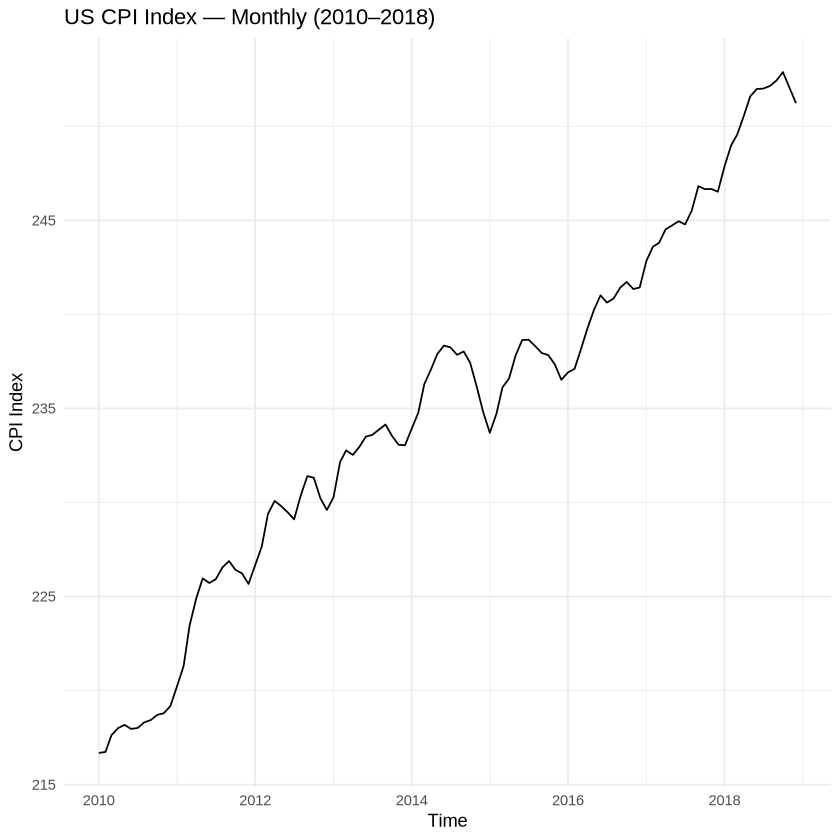

In [9]:
ggplot(df1, aes(x = time, y = y)) +
  geom_line() +
  labs(title = "US CPI Index — Monthly (2010–2018)",
       x = "Time", y = "CPI Index") +   # "y" is not informative
  theme_minimal()

In [10]:
summary(df1$y)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  216.7   229.3   236.1   235.1   241.4   252.9 

In [11]:
y_ts  <- ts(df1$y, start = c(2010, 1), end = c(2018, 12), frequency = 12)
y_tst <- ts(dft$y, start = c(2019, 1), end = c(2019, 12), frequency = 12)


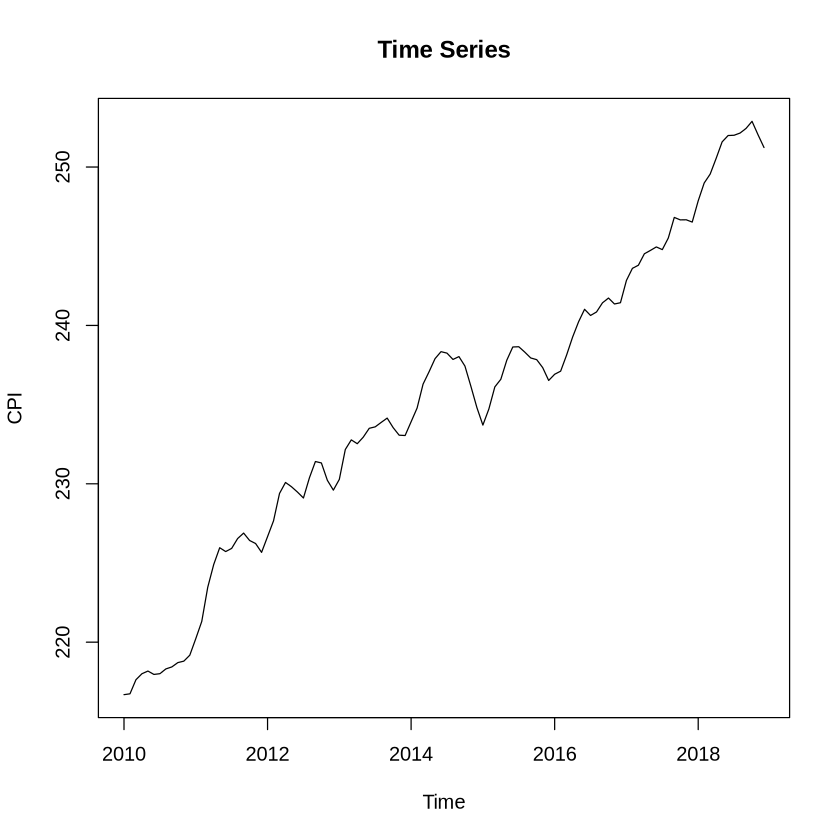

In [12]:
plot(y_ts, main = "Time Series", ylab = "CPI", xlab = "Time", )

* there seems to be some sort of a linear trend and a nearly stable variance

# 3. Variance Stabilization

In [13]:
lambda <- BoxCox.lambda(y_ts)
lambda

[1] 1.229031

### Box-Cox Transformation
The Guerrero method estimates an optimal lambda of **1.22**. Although close
to 1, the transformation is applied to formally stabilize the variance before
proceeding with stationarity testing and model fitting.
**this serves as a precaution only.**

In [14]:
y_bc <- BoxCox(y_ts, lambda)

# 4. Stationarity Testing

In [15]:
adf.test(y_bc)


	Augmented Dickey-Fuller Test

data:  y_bc
Dickey-Fuller = -2.6971, Lag order = 4, p-value = 0.2875
alternative hypothesis: stationary


### ADF Test — Result
The Augmented Dickey-Fuller test **fails to reject** the null hypothesis of a
unit root (p > 0.05), confirming the series is non-stationary. This is
consistent with the upward trend observed in the plot.

## estimation of the linear trend (deterministic model)

In [16]:
linear_model <- lm(y_bc ~ time(y_bc))
summary(linear_model)


Call:
lm(formula = y_bc ~ time(y_bc))

Residuals:
     Min       1Q   Median       3Q      Max 
-13.5540  -5.8325   0.2793   6.6909  11.8549 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2.483e+04  5.185e+02  -47.89   <2e-16 ***
time(y_bc)   1.266e+01  2.574e-01   49.17   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.949 on 106 degrees of freedom
Multiple R-squared:  0.958,	Adjusted R-squared:  0.9576 
F-statistic:  2418 on 1 and 106 DF,  p-value: < 2.2e-16


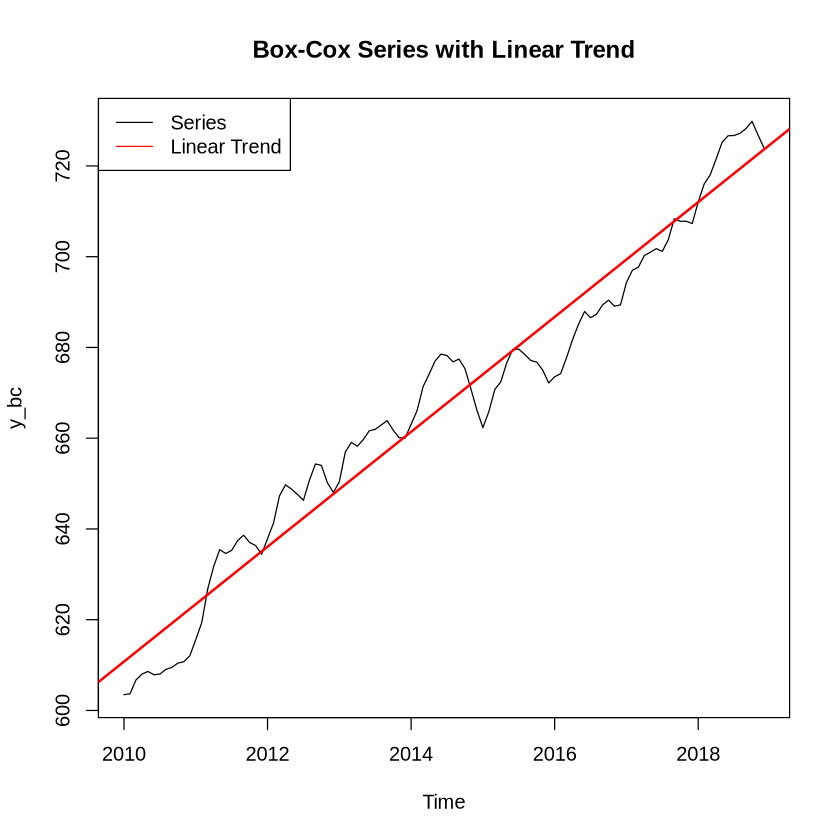

In [17]:
# Plot series + trend line
plot(y_bc, main = "Box-Cox Series with Linear Trend",
     ylab = "y_bc", col = "black")
abline(linear_model, col = "red", lwd = 2)
legend("topleft", legend = c("Series", "Linear Trend"),
       col = c("black", "red"), lty = 1)

In [18]:
# Residuals from linear model
res_linear <- residuals(linear_model)
res_linear_ts <- ts(res_linear, start = c(2010,1), frequency = 12)

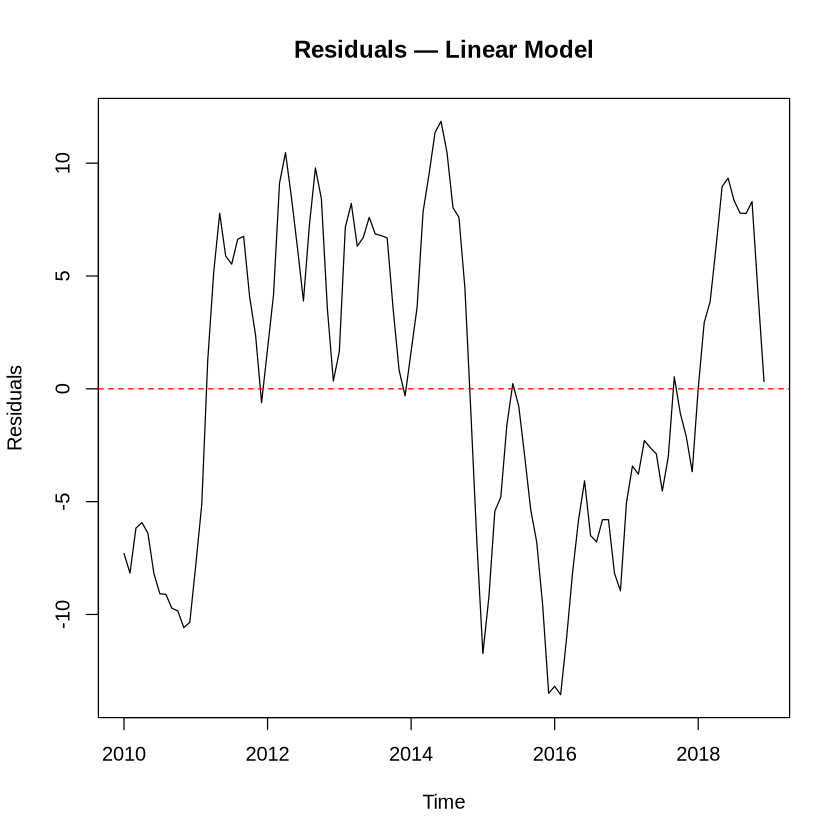

In [19]:
# Plot residuals
plot(res_linear_ts, type = "l",
     main = "Residuals — Linear Model",
     ylab = "Residuals")
abline(h = 0, col = "red", lty = 2)

* We notice that the residuals do not look like Gaussian white noise

In [20]:
adf.test(res_linear)
shapiro.test(res_linear)
runs.test(res_linear)


	Augmented Dickey-Fuller Test

data:  res_linear
Dickey-Fuller = -2.6971, Lag order = 4, p-value = 0.2875
alternative hypothesis: stationary



	Shapiro-Wilk normality test

data:  res_linear
W = 0.9488, p-value = 0.0003968



	Runs Test

data:  res_linear
statistic = -8.701, runs = 10, n1 = 54, n2 = 54, n = 108, p-value <
2.2e-16
alternative hypothesis: nonrandomness


### Linear Detrending — Diagnostic Results
The residuals from the linear model fail all three white noise tests:
1. **ADF:** Non-stationary — the residuals still contain a unit root
2. **Shapiro-Wilk:** Non-normal (p < 0.05) — residuals are not Gaussian
3. **Runs Test:** Non-independent — systematic structure remains

Linear detrending is insufficient.

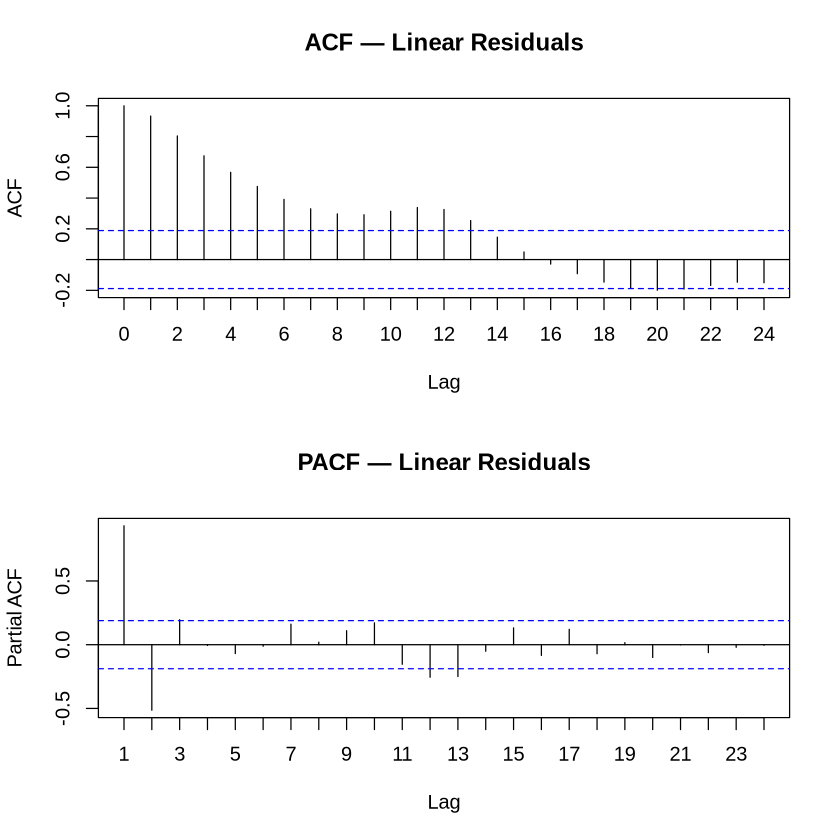

In [21]:
par(mfrow = c(2, 1))
acf(res_linear_ts,  lag.max = 24, xaxt = "n",
    main = "ACF — Linear Residuals")
axis(1, at = 0:24/12, labels = 0:24)
pacf(res_linear_ts, lag.max = 24, xaxt = "n",
     main = "PACF — Linear Residuals")
axis(1, at = 1:24/12, labels = 1:24)
par(mfrow = c(1, 1))

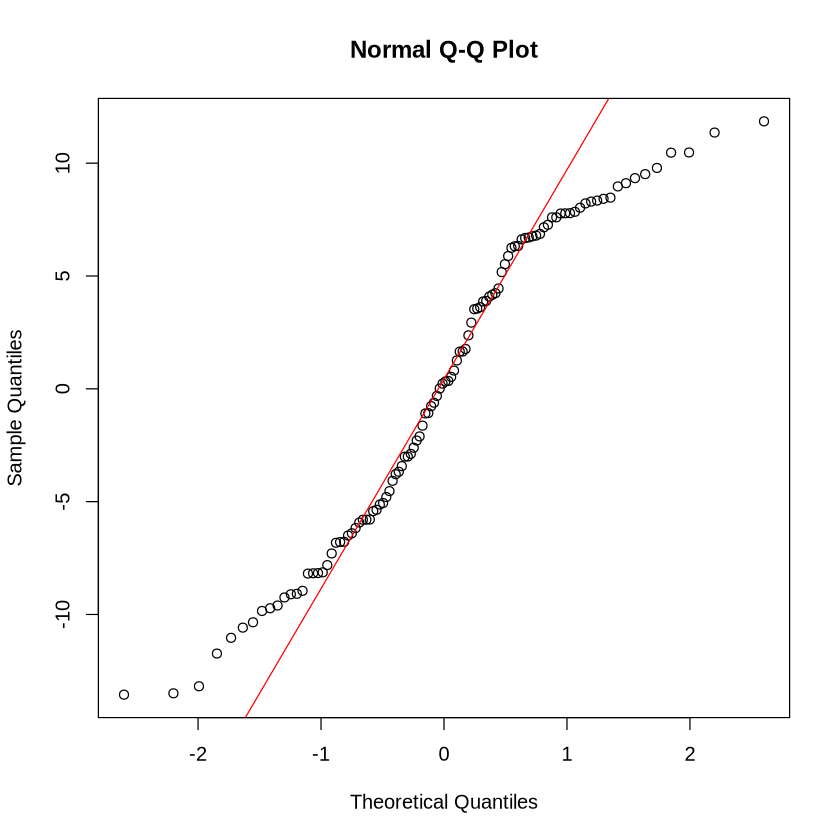

In [22]:
qqnorm(res_linear)
qqline(res_linear, col = "red")

* this indicates the non-normality too

## linear + sinusoidal:
since the regular linear model gave bad results in terms of the residuals being normal white noise, we will try this time a linear + sinusoidal trend since the residuals look seasonal


Call:
lm(formula = y_bc ~ t + cos_12 + sin_12)

Residuals:
    Min      1Q  Median      3Q     Max 
-12.340  -5.768   2.130   5.266   9.849 

Coefficients:
            Estimate Std. Error  t value Pr(>|t|)    
(Intercept) 667.2081     0.6316 1056.313  < 2e-16 ***
t            12.6614     0.2441   51.877  < 2e-16 ***
cos_12        3.4330     0.8933    3.843 0.000209 ***
sin_12       -0.1683     0.8967   -0.188 0.851479    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.564 on 104 degrees of freedom
Multiple R-squared:  0.9632,	Adjusted R-squared:  0.9622 
F-statistic: 908.4 on 3 and 104 DF,  p-value: < 2.2e-16


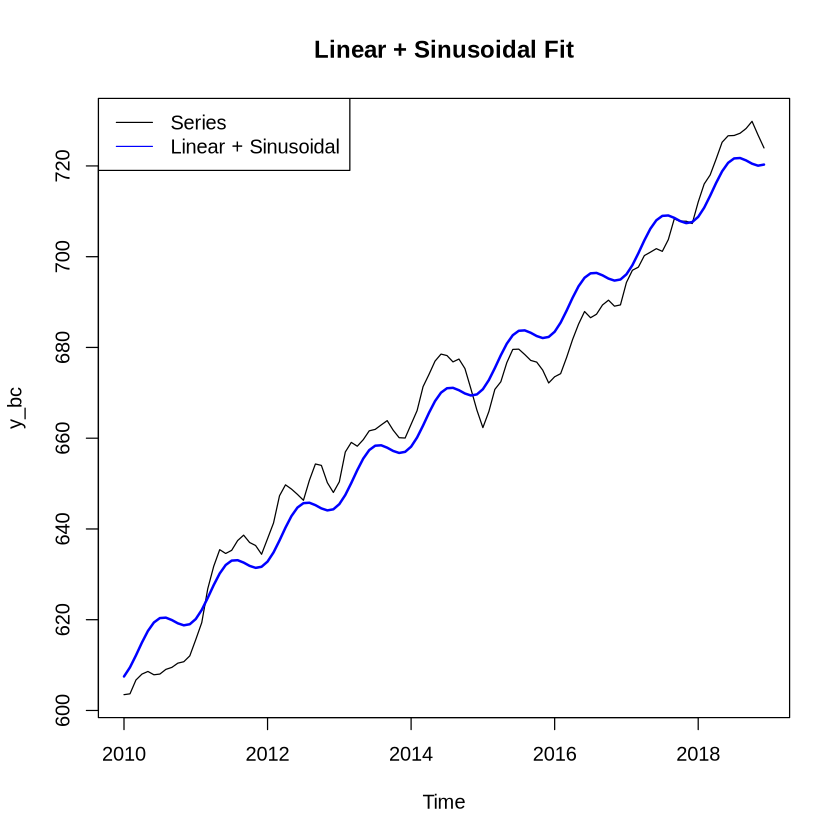

In [23]:
# Build sinusoidal terms (annual cycle = period 12)
time_index <- time(y_bc)
t <- as.numeric(time_index) - mean(as.numeric(time_index))
cos_12  <- cos(2 * pi * t)
sin_12  <- sin(2 * pi * t)

# Fit linear + sinusoidal
harmonic_model <- lm(y_bc ~ t + cos_12 + sin_12)
summary(harmonic_model)

fitted_ts <- ts(fitted(harmonic_model),
                start = start(y_bc),
                frequency = frequency(y_bc))

plot(y_bc, main = "Linear + Sinusoidal Fit",
     ylab = "y_bc", col = "black")
lines(fitted_ts, col = "blue", lwd = 2)
legend("topleft", legend = c("Series", "Linear + Sinusoidal"),
       col = c("black", "blue"), lty = 1)

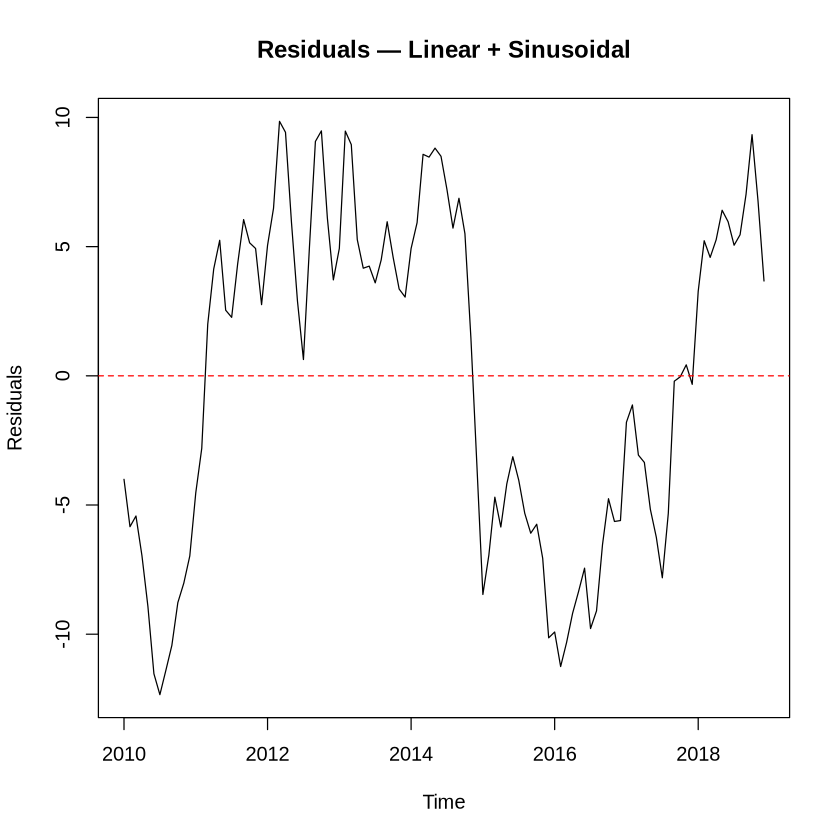

In [24]:
harmonic_residuals <- residuals(harmonic_model)
harmonic_residuals_ts <- ts(harmonic_residuals,
                            start = c(2010, 1), frequency = 12)

plot(harmonic_residuals_ts, type = "l",
     main = "Residuals — Linear + Sinusoidal",
     ylab = "Residuals")
abline(h = 0, col = "red", lty = 2)

In [25]:
adf.test(harmonic_residuals_ts)
shapiro.test(harmonic_residuals_ts)
runs.test(harmonic_residuals_ts)


	Augmented Dickey-Fuller Test

data:  harmonic_residuals_ts
Dickey-Fuller = -2.0998, Lag order = 4, p-value = 0.5353
alternative hypothesis: stationary



	Shapiro-Wilk normality test

data:  harmonic_residuals_ts
W = 0.92172, p-value = 8.511e-06



	Runs Test

data:  harmonic_residuals_ts
statistic = -9.4744, runs = 6, n1 = 54, n2 = 54, n = 108, p-value <
2.2e-16
alternative hypothesis: nonrandomness


* The diagnostics yield the same results as the purely linear model — the residuals remain non-stationary, non-normal, and serially dependent. Linear detrending with a sinusoidal component is therefore also insufficient.

### We will move on to the ARIMA family of fits

## detrending the box cox transformed Series

## 1. the linear trend

In [26]:
y_detrended <- ts(residuals(linear_model),
                  start = c(2010, 1), frequency = 12)

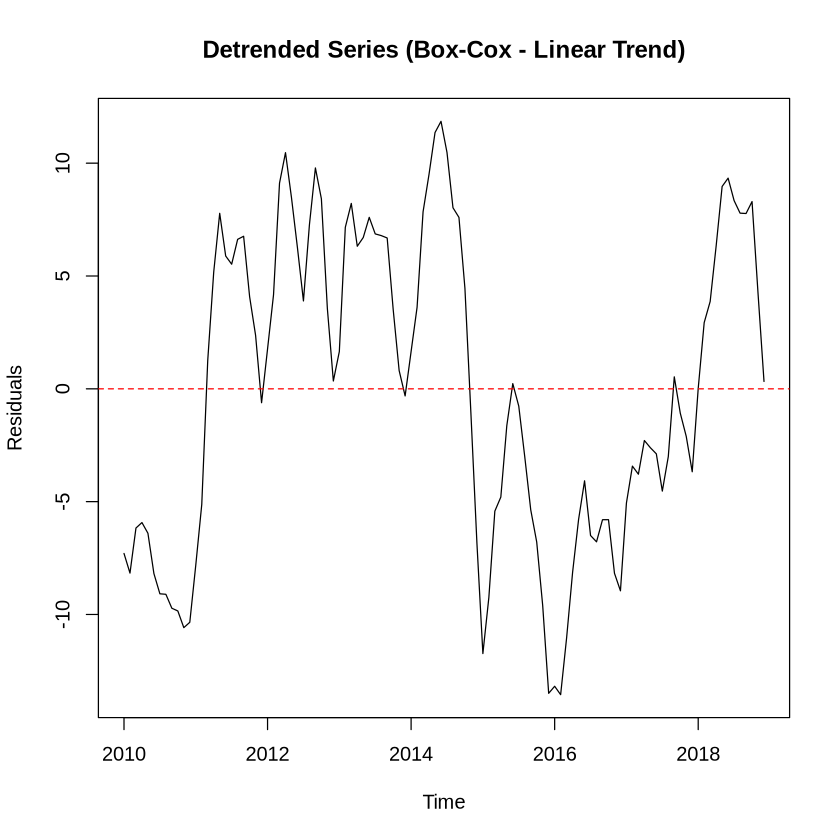

In [27]:
plot(y_detrended, type = "l",
     main = "Detrended Series (Box-Cox - Linear Trend)",
     ylab = "Residuals", xlab = "Time")
abline(h = 0, col = "red", lty = 2)

In [28]:
adf.test(y_detrended)


	Augmented Dickey-Fuller Test

data:  y_detrended
Dickey-Fuller = -2.6971, Lag order = 4, p-value = 0.2875
alternative hypothesis: stationary


* the ADF test still fails to reject the unit root hypothesis, indicating that detrending alone is insufficient to achieve stationarity.

## 2. differencing

In [29]:
y_diff <- diff(y_bc)

In [30]:
adf.test(y_diff)  # should pass now

Warning message in adf.test(y_diff):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  y_diff
Dickey-Fuller = -4.6659, Lag order = 4, p-value = 0.01
alternative hypothesis: stationary


### First Differencing — Result
The ADF test on the first-differenced series **rejects the null hypothesis**
(p < 0.05), confirming stationarity has been achieved. We set **d = 1**.

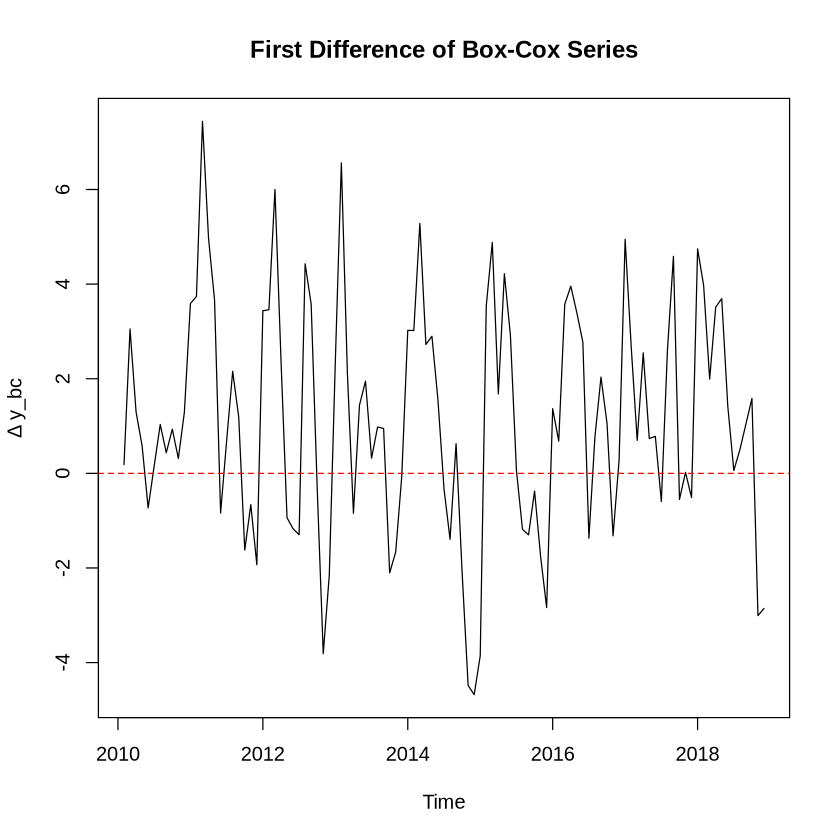

In [31]:
plot(y_diff, type = "l",
     main = "First Difference of Box-Cox Series",
     ylab = "Δ y_bc")
abline(h = 0, col = "red", lty = 2)

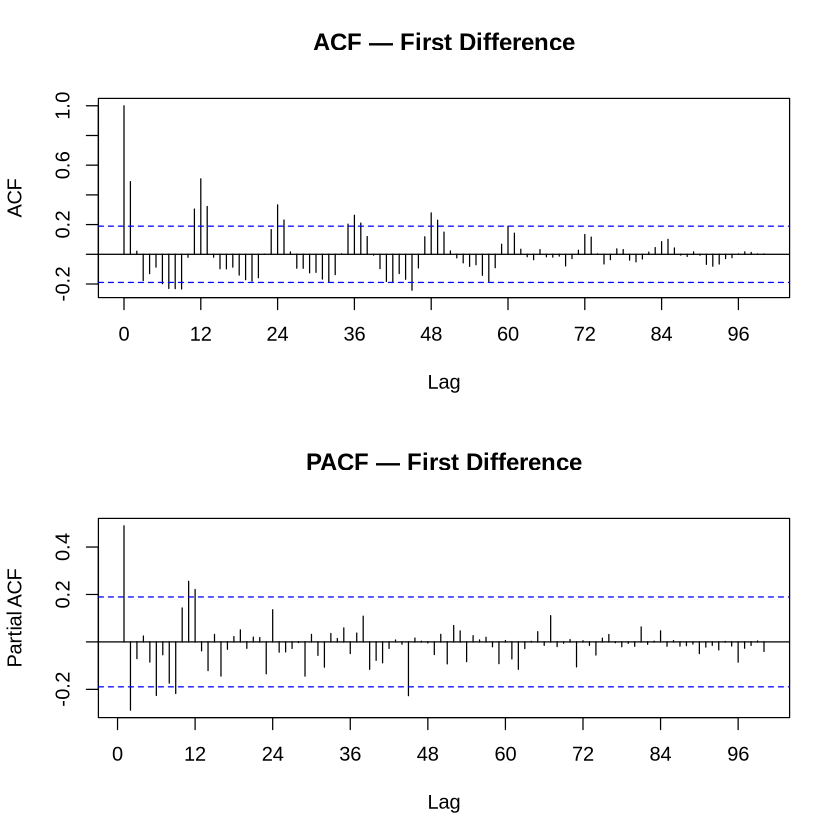

In [32]:
par(mfrow = c(2, 1))
acf(y_diff,  lag.max = 100, xaxt = "n",
    main = "ACF — First Difference")
axis(1, at = seq(0, 100 / 12, by = 1),
     labels = seq(0, 100, by = 12))

pacf(y_diff, lag.max = 100, xaxt = "n",
     main = "PACF — First Difference")
axis(1, at = seq(0, 100 / 12, by = 1),
     labels = seq(0, 100, by = 12))


* We can detect clear marks of seasonality with a period of 12 in both ACF and PACF, even though it cuts sharply in the PACF

* We can clearly notice from this that the ACF is tailing off instead of cutting off while the PACF is clearly cutting off at the spot after some lags. this suggets that an AR model is best in this case, with p either being 1 or 2.

- We notice a clear seasonality in the ACF and PACF of the first differenced Series, with a period of 12, this suggests we apply a seasonal difference with lag 12


In [33]:
y_diff2 <- diff(y_diff, lag = 12)

In [34]:
adf.test(y_diff2)


	Augmented Dickey-Fuller Test

data:  y_diff2
Dickey-Fuller = -3.7279, Lag order = 4, p-value = 0.02593
alternative hypothesis: stationary


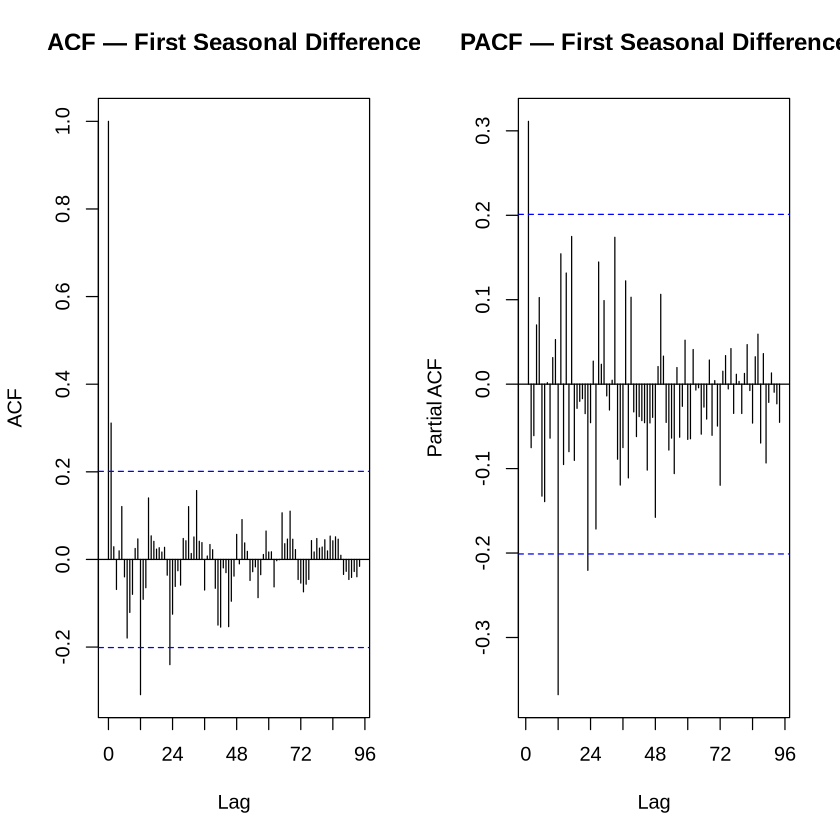

In [35]:
par(mfrow = c(1, 2))
acf(y_diff2,  lag.max = 100, xaxt = "n",
    main = "ACF — First Seasonal Difference")
axis(1, at = seq(0, 100 / 12, by = 1),
     labels = seq(0, 100, by = 12))

pacf(y_diff2, lag.max = 100, xaxt = "n",
     main = "PACF — First Seasonal Difference")
axis(1, at = seq(0, 100 / 12, by = 1),
     labels = seq(0, 100, by = 12))

### Conclusion:
After revising the final ACF and PACF yielded from seasonal and regular differencing: 
- we needed differencing for stationarity, d=1
- we needed seasonal differencing so we can see that D=1
- from the PACF we can see that p should be either 0 or 1
- since the ACF of the seasonal difference is cutting off and not tailing off after taking the seasonality difference,  we can infer the seeming presence of an MA component with q=1

# 5. fitting

#### Here We will try fitting some of the models that we have decided upon in the previous section and compare them to the model that R suggests using the auto.arima estimation functionality

### 1. fitting an ARIMA to the box cox transformed Series

In [36]:
library(forecast)
arima_model <- auto.arima(y_bc, seasonal = TRUE,
                          stepwise = FALSE, approximation = FALSE)
summary(arima_model)

Series: y_bc 
ARIMA(1,1,0)(0,1,1)[12] 

Coefficients:
         ar1     sma1
      0.3689  -0.8443
s.e.  0.0970   0.1935

sigma^2 = 3.312:  log likelihood = -197.21
AIC=400.42   AICc=400.68   BIC=408.08

Training set error measures:
                        ME     RMSE      MAE           MPE      MAPE       MASE
Training set -0.0001417011 1.688712 1.293372 -0.0004044808 0.1925817 0.08920907
                  ACF1
Training set 0.0244368

### 2. fitting other models from the results of the previous section

In [54]:
m1 <- arima(y_bc, order = c(0, 1, 1))

summary(m1)


Call:
arima(x = y_bc, order = c(0, 1, 1))

Coefficients:
         ma1
      0.5697
s.e.  0.0677

sigma^2 estimated as 4.814:  log likelihood = -236.1,  aic = 476.21

Training set error measures:
                    ME     RMSE      MAE       MPE      MAPE      MASE
Training set 0.7133742 2.184775 1.671831 0.1076527 0.2508837 0.1153129
                   ACF1
Training set 0.04120272

In [38]:
m2 <- arima(y_bc, order = c(2, 1, 0),
            seasonal = list(order = c(0,1,1), period = 12))

summary(m2)


Call:
arima(x = y_bc, order = c(2, 1, 0), seasonal = list(order = c(0, 1, 1), period = 12))

Coefficients:
         ar1      ar2     sma1
      0.4184  -0.1426  -0.8858
s.e.  0.1028   0.1035   0.2576

sigma^2 estimated as 3.046:  log likelihood = -196.27,  aic = 400.54

Training set error measures:
                       ME     RMSE      MAE          MPE      MAPE       MASE
Training set -0.007025741 1.649734 1.261686 -0.001550661 0.1878782 0.08702359
                    ACF1
Training set -0.02416379

In [39]:
m3 <- arima(y_bc, order = c(0, 1, 1),
            seasonal = list(order = c(0, 1, 1), period = 12))
summary(m3)


Call:
arima(x = y_bc, order = c(0, 1, 1), seasonal = list(order = c(0, 1, 1), period = 12))

Coefficients:
         ma1     sma1
      0.4028  -0.8921
s.e.  0.0916   0.2639

sigma^2 estimated as 3.042:  log likelihood = -196.42,  aic = 398.84

Training set error measures:
                       ME     RMSE      MAE          MPE      MAPE       MASE
Training set -0.004538434 1.648715 1.250892 -0.001174297 0.1863437 0.08627908
                    ACF1
Training set -0.01249978

In [40]:
m4 <- arima(y_bc, order = c(0, 1, 1),
            seasonal = list(order = c(0, 1, 0), period = 12))
summary(m4)


Call:
arima(x = y_bc, order = c(0, 1, 1), seasonal = list(order = c(0, 1, 0), period = 12))

Coefficients:
         ma1
      0.3062
s.e.  0.0900

sigma^2 estimated as 5.086:  log likelihood = -212.11,  aic = 428.21

Training set error measures:
                     ME     RMSE      MAE       MPE     MAPE      MASE
Training set 0.01573051 2.125175 1.670908 0.0023221 0.249031 0.1152492
                    ACF1
Training set 0.009514558

### Comparing the different models

In [49]:
AIC(m1, m2, m3, m4, arima_model)

Warning message in AIC.default(m1, m2, m3, m4, arima_model):
“models are not all fitted to the same number of observations”


,df,AIC
,<dbl>,<dbl>
m1,2,473.4010
m2,4,400.5383
m3,3,398.8382
m4,2,428.2115
arima_model,3,400.4160


In [50]:
BIC(m1, m2, m3, m4, arima_model)

Warning message in BIC.default(m1, m2, m3, m4, arima_model):
“models are not all fitted to the same number of observations”


,df,BIC
,<dbl>,<dbl>
m1,2,478.7466
m2,4,410.7538
m3,3,406.4999
m4,2,433.3192
arima_model,3,408.0776


while these criteria consistently favor m3, they rank models relatively and do not confirm whether the model is adequate in absolute terms — hence the need for residual diagnostics. we will analyze the best 2 models: m3 and arima_model.


# 6. Analysis of residuals on the best two models

### Auto Arima


	Box-Ljung test

data:  res
X-squared = 20.036, df = 20, p-value = 0.4557



	Shapiro-Wilk normality test

data:  res[-1]
W = 0.98396, p-value = 0.2263



	Runs Test

data:  res[-1]
statistic = -0.78076, runs = 50, n1 = 53, n2 = 53, n = 106, p-value =
0.4349
alternative hypothesis: nonrandomness


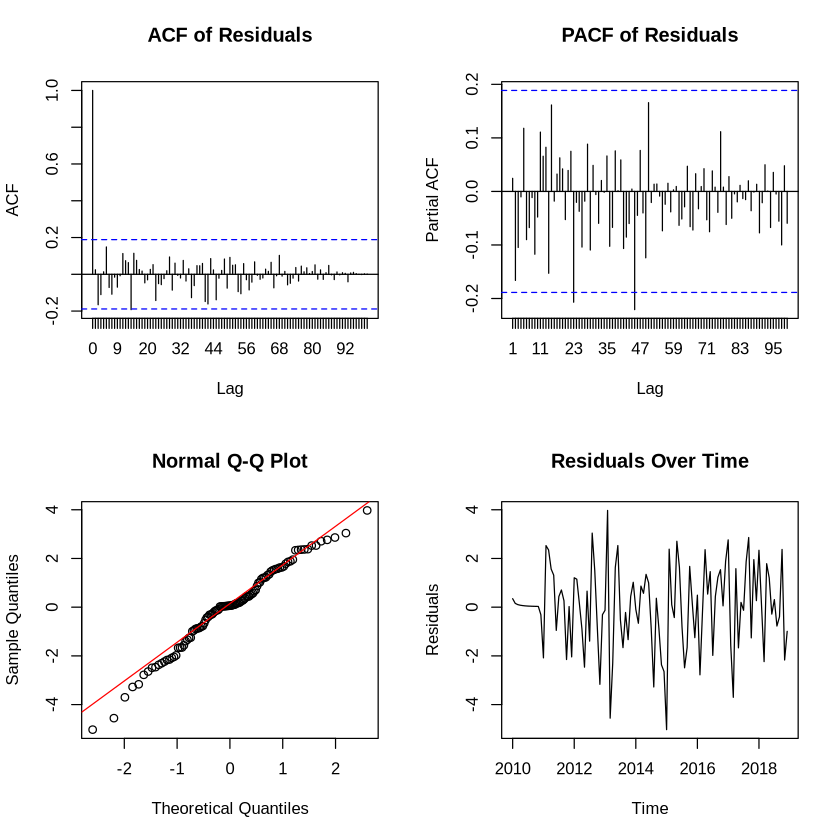

In [43]:
res <- residuals(arima_model)

Box.test(res, lag = 20, type = "Ljung-Box")
shapiro.test(res[-1])
runs.test(res[-1])

par(mfrow = c(2, 2))

acf(res,
    lag.max = 100,
    xaxt    = "n",
    main    = "ACF of Residuals")
axis(1, at = 0:100/12, labels = 0:100)

pacf(res,
     lag.max = 100,
     xaxt    = "n",
     main    = "PACF of Residuals")
axis(1, at = 1:100/12, labels = 1:100)


qqnorm(res[-1])
qqline(res[-1], col = "red")
plot(res, type = "l", main = "Residuals Over Time", ylab = "Residuals")

### M3


	Box-Ljung test

data:  m3_res
X-squared = 16.418, df = 20, p-value = 0.6904



	Shapiro-Wilk normality test

data:  m3_res[-1]
W = 0.98261, p-value = 0.1758



	Runs Test

data:  m3_res[-1]
statistic = -0.78076, runs = 50, n1 = 53, n2 = 53, n = 106, p-value =
0.4349
alternative hypothesis: nonrandomness


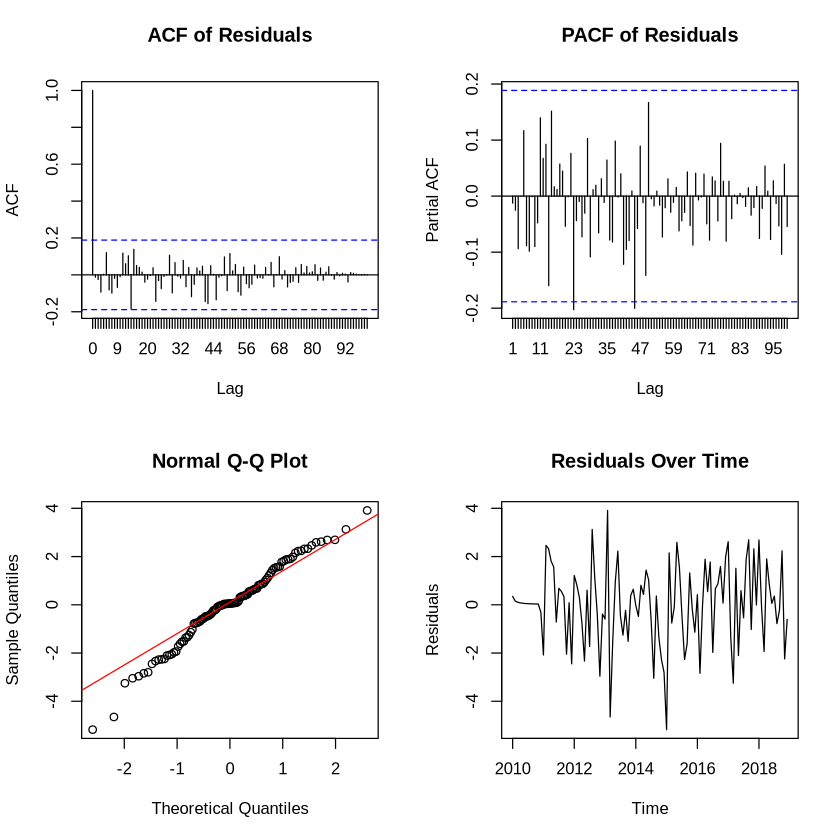

In [44]:
m3_res <- residuals(m3)

Box.test(m3_res, lag = 20, type = "Ljung-Box")
shapiro.test(m3_res[-1])
runs.test(m3_res[-1])

par(mfrow = c(2, 2))

acf(m3_res,
    lag.max = 100,
    xaxt    = "n",
    main    = "ACF of Residuals")
axis(1, at = 0:100/12, labels = 0:100)

pacf(m3_res,
     lag.max = 100,
     xaxt    = "n",
     main    = "PACF of Residuals")
axis(1, at = 1:100/12, labels = 1:100)
qqnorm(m3_res[-1])
qqline(m3_res[-1], col = "red")
plot(m3_res, type = "l", main = "Residuals Over Time", ylab = "Residuals")

- We observe that both models have Gaussian White noise Residuals as:

1. Both fail to reject the normality hypothesis (Shapiro-Wilk p = 0.226 and p = 0.176 respectively, both > 0.05)
2. both the runs test and the Ljung-Box tests fail to reject the independence hypothesis

#### so we can conclude that both of them have modeled the deterministic part successfully.


# 7. Forecasting 
 We have chosen the 2 best models based on AIC, BIC, and on how much they pass the tests based off the p-values. now let us test them through forecast

In [45]:
fca <- forecast(arima_model, h = 12, lambda = lambda)
fcm <- forecast(m3, h = 12, lambda = lambda)

Warning message in InvBoxCox(pred$pred, lambda, biasadj, pred$se^2):
“biasadj information not found, defaulting to FALSE.”
Warning message in InvBoxCox(pred$pred, lambda, biasadj, pred$se^2):
“biasadj information not found, defaulting to FALSE.”


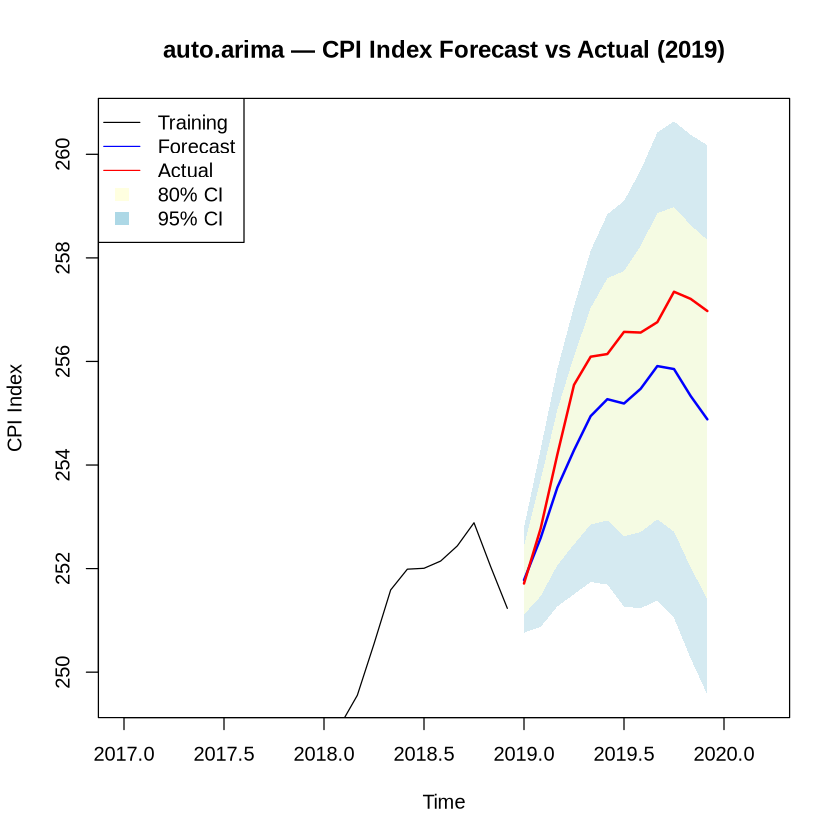

In [46]:
# Back-transform training series to original scale for plotting
y_ts_orig <- InvBoxCox(y_bc, lambda)

plot(y_ts_orig,
     xlim = c(2017, 2020.2),
     ylim = range(c(fca$lower, fca$upper, y_tst), na.rm = TRUE),
     main = "auto.arima — CPI Index Forecast vs Actual (2019)",
     ylab = "CPI Index", xlab = "Time",
     col  = "black", lwd = 1)

polygon(c(time(fca$mean), rev(time(fca$mean))),
        c(fca$lower[,2], rev(fca$upper[,2])),
        col = adjustcolor("lightblue", alpha.f = 0.5), border = NA)
polygon(c(time(fca$mean), rev(time(fca$mean))),
        c(fca$lower[,1], rev(fca$upper[,1])),
        col = adjustcolor("lightyellow", alpha.f = 0.8), border = NA)

lines(fca$mean, col = "blue",  lwd = 2)  # forecast already back-transformed
lines(y_tst,    col = "red",   lwd = 2)  # actual in original scale

legend("topleft",
       legend = c("Training", "Forecast", "Actual", "80% CI", "95% CI"),
       col    = c("black", "blue", "red", "lightyellow", "lightblue"),
       lty    = c(1, 1, 1, NA, NA),
       pch    = c(NA, NA, NA, 15, 15),
       pt.cex = 1.5)

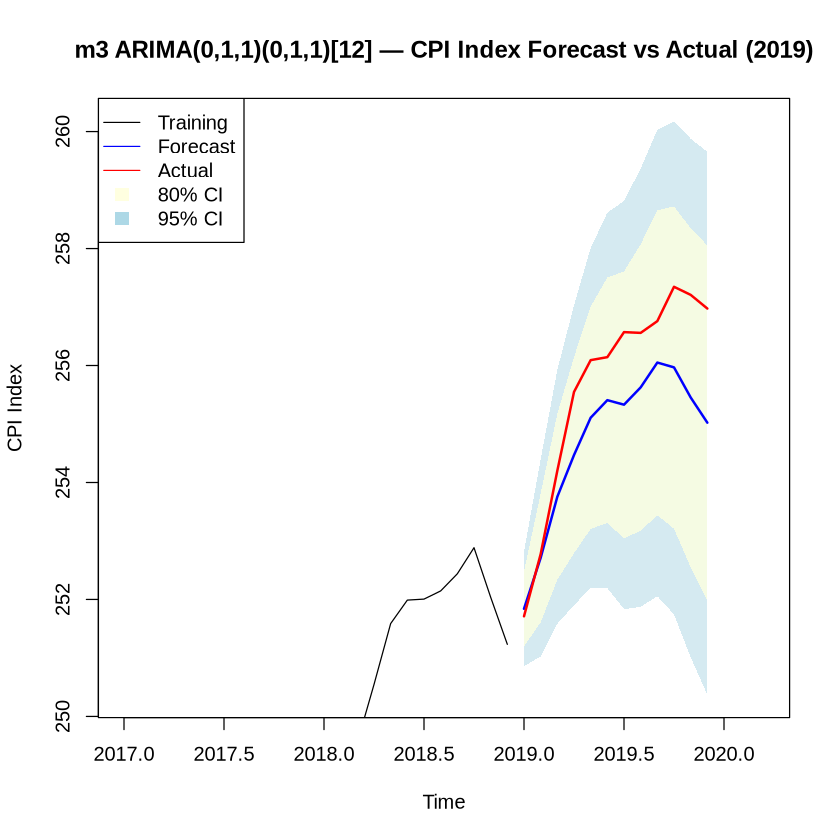

In [47]:
# --- m3 plot ---
plot(y_ts_orig,
     xlim = c(2017, 2020.2),
     ylim = range(c(fcm$lower, fcm$upper, y_tst), na.rm = TRUE),
     main = "m3 ARIMA(0,1,1)(0,1,1)[12] — CPI Index Forecast vs Actual (2019)",
     ylab = "CPI Index", xlab = "Time",
     col  = "black", lwd = 1)

polygon(c(time(fcm$mean), rev(time(fcm$mean))),
        c(fcm$lower[,2], rev(fcm$upper[,2])),
        col = adjustcolor("lightblue", alpha.f = 0.5), border = NA)
polygon(c(time(fcm$mean), rev(time(fcm$mean))),
        c(fcm$lower[,1], rev(fcm$upper[,1])),
        col = adjustcolor("lightyellow", alpha.f = 0.8), border = NA)

lines(fcm$mean, col = "blue", lwd = 2)
lines(y_tst,    col = "red",  lwd = 2)

legend("topleft",
       legend = c("Training", "Forecast", "Actual", "80% CI", "95% CI"),
       col    = c("black", "blue", "red", "lightyellow", "lightblue"),
       lty    = c(1, 1, 1, NA, NA),
       pch    = c(NA, NA, NA, 15, 15),
       pt.cex = 1.5)

In [48]:
cat("--- auto.arima ---\n")
accuracy(fca, y_tst)

cat("--- m3 ---\n")
accuracy(fcm, y_tst)

--- auto.arima ---


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.0001417011,1.688712,1.293372,-0.0004044808,0.1925817,0.08920907,0.0244368,NA
Test set,1.0675232750,1.226093,1.078631,0.4161731761,0.4205862,0.07439756,0.5307234,1.726014


--- m3 ---


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.004538434,1.648715,1.2508921,-0.001174297,0.1863437,0.08627908,-0.01249978,NA
Test set,0.928642387,1.102481,0.9500622,0.361878456,0.3703881,0.06552963,0.54589673,1.550725


| Metric | auto.arima ARIMA(1,1,0)(0,1,1)[12] | m3 ARIMA(0,1,1)(0,1,1)[12] | Winner |
|--------|--------------------------------------|------------------------------|--------|
| RMSE   | 1.226                                | **1.102**                    | m3 🥇  |
| MAE    | 1.079                                | **0.950**                    | m3 🥇  |
| MAPE   | 0.421%                               | **0.370%**                   | m3 🥇  |
| MASE   | 0.074                                | **0.066**                    | m3 🥇  |
| Theil's U | 1.726                             | **1.551**                    | m3 🥇  |
| AIC    | 400.42                               | **398.84**                   | m3 🥇  |
| BIC    | 408.08                               | **406.50**                   | m3 🥇  |
| Ljung-Box p | 0.456                         | 0.690                      | —      |
| Shapiro-Wilk p | 0.226                     | 0.176                      | —      |

## Conclusion

Both models produce forecasts that closely track the actual 2019 CPI Index,
with all actual values falling within the 95% prediction interval.

**m3 — ARIMA(0,1,1)(0,1,1)[12]** outperforms auto.arima on every accuracy
metric and also achieves lower AIC and BIC.

This model is well-known in the time series literature as the **airline model** (Box & Jenkins, 1970) — is
particularly well-suited to CPI data: the non-seasonal MA(1) term captures
short-term month-to-month price momentum, while the seasonal MA(1) term
captures the annual cycle in price changes. Both differencing orders (d=1, D=1) were necessary to achieve full stationarity.